# PaySim Exploratory Data Analysis

**WBS task:** T3

T3 — Profile the 6.36M transactions, characterize the 0.1291% fraud rate, identify hub-and-spoke / smurfing motifs.

**Runs on:** Kaggle Notebooks (P100/T4) or local. Add the `ealaxi/paysim1` dataset on Kaggle.

Header pattern for all notebooks in this repo:

```python
# Portable dataset path — works on Kaggle and locally
import os
if os.path.exists('/kaggle/input/paysim1'):
    DATA_PATH = '/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv'
else:
    DATA_PATH = './data/raw/PS_20174392719_1491204439457_log.csv'
```


In [1]:
# Setup — imports + portable dataset path
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Auto-detect dataset location (works on Kaggle and local)
if os.path.exists('/kaggle/input/paysim1'):
    DATA_PATH = '/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv'
else:
    DATA_PATH = Path(__file__).parent.parent / 'data' / 'raw' / 'PS_20174392719_1491204439457_log.csv' if '__file__' in globals() else '../data/raw/PS_20174392719_1491204439457_log.csv'

print(f"Dataset path: {DATA_PATH}")
print(f"File exists: {os.path.exists(DATA_PATH)}")
print(f"File size: {os.path.getsize(DATA_PATH) / 1024**2:.1f} MB")


Dataset path: ../data/raw/PS_20174392719_1491204439457_log.csv
File exists: True
File size: 470.7 MB


In [2]:
# Naive load — see how much RAM it costs without optimization
import time

t0 = time.time()
df_naive = pd.read_csv(DATA_PATH)
t1 = time.time()

print(f"Load time: {t1-t0:.1f}s")
print(f"Rows: {len(df_naive):,}")
print(f"Columns: {df_naive.columns.tolist()}")
print(f"Memory usage: {df_naive.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"\nDtypes:")
print(df_naive.dtypes)


Load time: 4.6s
Rows: 6,362,620
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Memory usage: 1.42 GB

Dtypes:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [3]:
# Optimized dtypes — same data, ~70% less RAM
del df_naive  # free the naive version first
import gc; gc.collect()

dtypes = {
    'step': 'int16',           # max 743
    'type': 'category',        # only 5 unique values
    'amount': 'float32',
    'nameOrig': 'category',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'category',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8',
}

t0 = time.time()
df = pd.read_csv(DATA_PATH, dtype=dtypes)
t1 = time.time()

print(f"Load time: {t1-t0:.1f}s")
print(f"Rows: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"\nFirst 5 rows:")
df.head()


Load time: 19.5s
Rows: 6,362,620
Memory usage: 0.89 GB

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


In [4]:
# Column dictionary — what each PaySim column means
column_meanings = {
    'step':           'Time unit (1 step = 1 hour). Range 1-743 covers ~31 days of activity.',
    'type':           'Transaction category. 5 values: PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT.',
    'amount':         'Transaction amount in local currency.',
    'nameOrig':       'Originating account ID (sender). Format: C followed by digits.',
    'oldbalanceOrg':  'Sender balance BEFORE the transaction.',
    'newbalanceOrig': 'Sender balance AFTER the transaction.',
    'nameDest':       'Destination account ID (receiver). Format: C (customer) or M (merchant).',
    'oldbalanceDest': 'Receiver balance BEFORE the transaction.',
    'newbalanceDest': 'Receiver balance AFTER the transaction.',
    'isFraud':        'GROUND TRUTH label: 1 = fraud, 0 = legitimate.',
    'isFlaggedFraud': "Legacy rule-based flag (>200,000 single transfer). The system we're trying to beat.",
}

for col, meaning in column_meanings.items():
    print(f"{col:20s} → {meaning}")


step                 → Time unit (1 step = 1 hour). Range 1-743 covers ~31 days of activity.
type                 → Transaction category. 5 values: PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT.
amount               → Transaction amount in local currency.
nameOrig             → Originating account ID (sender). Format: C followed by digits.
oldbalanceOrg        → Sender balance BEFORE the transaction.
newbalanceOrig       → Sender balance AFTER the transaction.
nameDest             → Destination account ID (receiver). Format: C (customer) or M (merchant).
oldbalanceDest       → Receiver balance BEFORE the transaction.
newbalanceDest       → Receiver balance AFTER the transaction.
isFraud              → GROUND TRUTH label: 1 = fraud, 0 = legitimate.
isFlaggedFraud       → Legacy rule-based flag (>200,000 single transfer). The system we're trying to beat.


In [5]:
# Q2 — Overall class balance
total = len(df)
fraud = df['isFraud'].sum()
legit = total - fraud

print(f"Total transactions:       {total:,}")
print(f"Fraud transactions:       {fraud:,}")
print(f"Legitimate transactions:  {legit:,}")
print(f"Fraud rate:               {fraud/total*100:.4f}%")
print(f"Imbalance ratio:          {legit/fraud:.1f} : 1  (legit : fraud)")


Total transactions:       6,362,620
Fraud transactions:       8,213
Legitimate transactions:  6,354,407
Fraud rate:               0.1291%
Imbalance ratio:          773.7 : 1  (legit : fraud)


In [6]:
# Q3 — Fraud rate per transaction type
type_breakdown = df.groupby('type', observed=True).agg(
    total_count=('isFraud', 'size'),
    fraud_count=('isFraud', 'sum'),
).assign(
    fraud_rate_pct=lambda x: (x['fraud_count'] / x['total_count'] * 100).round(4),
    pct_of_all_fraud=lambda x: (x['fraud_count'] / x['fraud_count'].sum() * 100).round(2),
).sort_values('fraud_count', ascending=False)

print("Per-type breakdown:\n")
print(type_breakdown)


Per-type breakdown:

          total_count  fraud_count  fraud_rate_pct  pct_of_all_fraud
type                                                                
CASH_OUT      2237500         4116          0.1840             50.12
TRANSFER       532909         4097          0.7688             49.88
CASH_IN       1399284            0          0.0000              0.00
DEBIT           41432            0          0.0000              0.00
PAYMENT       2151495            0          0.0000              0.00


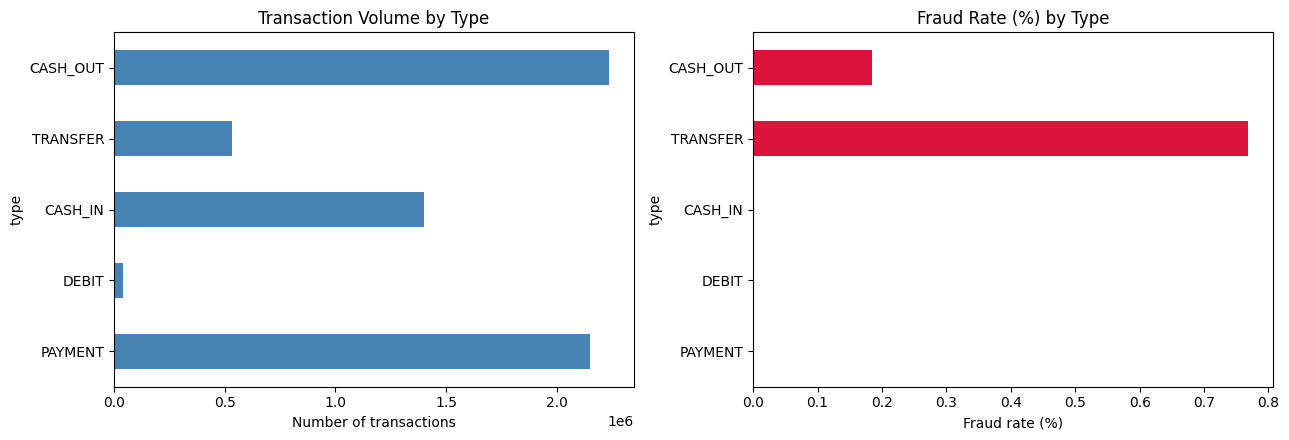

Saved figure to data/processed/fig_fraud_by_type.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: total transaction volume by type
type_breakdown['total_count'].plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Transaction Volume by Type')
axes[0].set_xlabel('Number of transactions')
axes[0].invert_yaxis()

# Right: fraud rate by type
type_breakdown['fraud_rate_pct'].plot(
    kind='barh', ax=axes[1], color='crimson'
)
axes[1].set_title('Fraud Rate (%) by Type')
axes[1].set_xlabel('Fraud rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/fig_fraud_by_type.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure to data/processed/fig_fraud_by_type.png")


In [8]:
# Q4 — How well does the legacy rule (isFlaggedFraud) actually catch fraud?
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = df['isFraud']
y_legacy = df['isFlaggedFraud']

tn, fp, fn, tp = confusion_matrix(y_true, y_legacy).ravel()

print("Confusion matrix for the LEGACY isFlaggedFraud rule:\n")
print(f"  True Positive  (caught fraud):     {tp:>6,}")
print(f"  False Negative (MISSED fraud):     {fn:>6,}  ← the problem")
print(f"  False Positive (false alarm):      {fp:>6,}")
print(f"  True Negative  (correctly ignored): {tn:>9,}")

print("\n" + "=" * 60)
print("Performance of the legacy rule:")
print("=" * 60)
print(f"  Precision:  {precision_score(y_true, y_legacy):.4f}")
print(f"  Recall:     {recall_score(y_true, y_legacy):.4f}  ← catches only this fraction of fraud")
print(f"  F1-score:   {f1_score(y_true, y_legacy):.4f}")
print(f"  Miss rate:  {fn / (tp + fn) * 100:.2f}%  ← THIS is what we're improving")


Confusion matrix for the LEGACY isFlaggedFraud rule:

  True Positive  (caught fraud):         16
  False Negative (MISSED fraud):      8,197  ← the problem
  False Positive (false alarm):           0
  True Negative  (correctly ignored): 6,354,407

Performance of the legacy rule:
  Precision:  1.0000
  Recall:     0.0019  ← catches only this fraction of fraud
  F1-score:   0.0039
  Miss rate:  99.81%  ← THIS is what we're improving


In [9]:
# Q4b — When the rule DOES fire, what does it look like? When it MISSES, why?
flagged = df[df['isFlaggedFraud'] == 1]
missed = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)]

print(f"Total flagged transactions: {len(flagged):,}")
print(f"Total missed frauds:        {len(missed):,}\n")

print("WHEN THE RULE FIRES — what amounts trigger it?")
print(f"  Min amount:    {flagged['amount'].min():>15,.2f}")
print(f"  Mean amount:   {flagged['amount'].mean():>15,.2f}")
print(f"  Max amount:    {flagged['amount'].max():>15,.2f}\n")

print("WHEN THE RULE MISSES — what do those frauds look like?")
print(f"  Min amount:    {missed['amount'].min():>15,.2f}")
print(f"  Median amount: {missed['amount'].median():>15,.2f}")
print(f"  Mean amount:   {missed['amount'].mean():>15,.2f}")
print(f"  Max amount:    {missed['amount'].max():>15,.2f}")
print(f"\n  Frauds UNDER 200,000:  {(missed['amount'] < 200_000).sum():,}  ({(missed['amount'] < 200_000).mean()*100:.1f}%)")
print(f"  Frauds OVER 200,000:   {(missed['amount'] >= 200_000).sum():,}  ({(missed['amount'] >= 200_000).mean()*100:.1f}%)")


Total flagged transactions: 16
Total missed frauds:        8,197

WHEN THE RULE FIRES — what amounts trigger it?
  Min amount:         353,874.22
  Mean amount:      4,861,598.00
  Max amount:      10,000,000.00

WHEN THE RULE MISSES — what do those frauds look like?
  Min amount:               0.00
  Median amount:      438,983.44
  Mean amount:      1,461,343.12
  Max amount:      10,000,000.00

  Frauds UNDER 200,000:  2,742  (33.5%)
  Frauds OVER 200,000:   5,455  (66.5%)


In [10]:
# Q5 — How do fraud and legitimate amounts compare? (only TRANSFER + CASH_OUT)
df_relevant = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

stats = df_relevant.groupby('isFraud', observed=True)['amount'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)
print("Amount distribution (TRANSFER + CASH_OUT only):\n")
print(stats.round(2))

print("\n--- Practical observations ---")
print(f"Median fraud amount:      {df_relevant[df_relevant['isFraud']==1]['amount'].median():>15,.2f}")
print(f"Median legitimate amount: {df_relevant[df_relevant['isFraud']==0]['amount'].median():>15,.2f}")
print(f"Mean fraud amount:        {df_relevant[df_relevant['isFraud']==1]['amount'].mean():>15,.2f}")
print(f"Mean legitimate amount:   {df_relevant[df_relevant['isFraud']==0]['amount'].mean():>15,.2f}")


Amount distribution (TRANSFER + CASH_OUT only):

             count        mean         std   min        25%        50%  \
isFraud                                                                  
0        2762196.0   314115.50   877144.19  0.01   82908.23  171034.46   
1           8213.0  1467967.38  2404253.00  0.00  127091.33  441423.44   

               75%         95%          99%         max  
isFraud                                                  
0         305994.2   942414.67   2580263.86  92445520.0  
1        1517771.5  8006429.00  10000000.00  10000000.0  

--- Practical observations ---
Median fraud amount:           441,423.44
Median legitimate amount:      171,034.47
Mean fraud amount:           1,467,967.38
Mean legitimate amount:        314,115.50


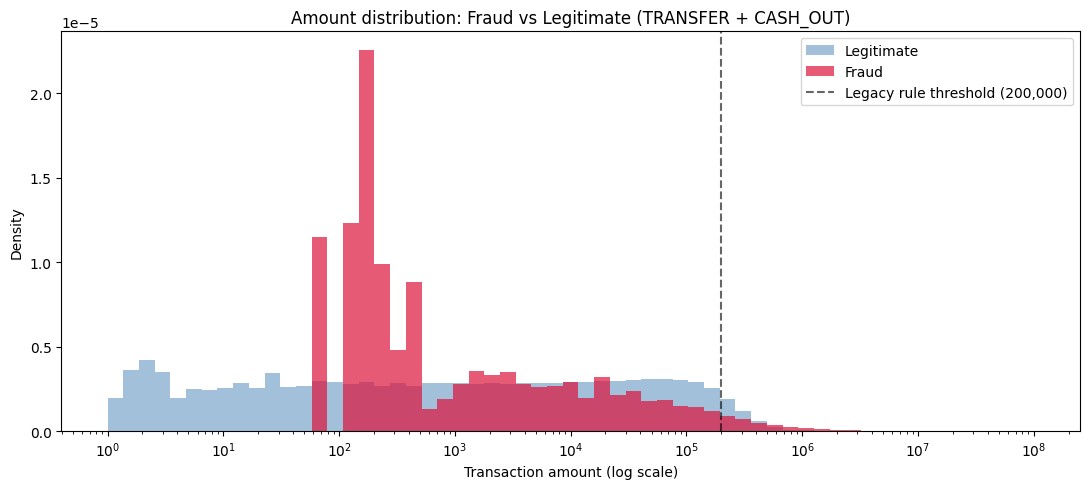

Saved figure to data/processed/fig_amount_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

bins = np.logspace(0, 8, 60)  # log-spaced bins from 1 to 100M

ax.hist(
    df_relevant[df_relevant['isFraud']==0]['amount'],
    bins=bins, alpha=0.5, label='Legitimate', color='steelblue', density=True
)
ax.hist(
    df_relevant[df_relevant['isFraud']==1]['amount'],
    bins=bins, alpha=0.7, label='Fraud', color='crimson', density=True
)
ax.set_xscale('log')
ax.set_xlabel('Transaction amount (log scale)')
ax.set_ylabel('Density')
ax.set_title('Amount distribution: Fraud vs Legitimate (TRANSFER + CASH_OUT)')
ax.axvline(200_000, color='black', linestyle='--', alpha=0.6, label='Legacy rule threshold (200,000)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_amount_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure to data/processed/fig_amount_distribution.png")


In [12]:
# Q6 — When does fraud happen? (1 step = 1 hour)
fraud_per_step = df.groupby('step', observed=True)['isFraud'].agg(['sum', 'size'])
fraud_per_step.columns = ['fraud_count', 'total_count']
fraud_per_step['fraud_rate'] = fraud_per_step['fraud_count'] / fraud_per_step['total_count']

# Convert step to "day"
fraud_per_step['day'] = (fraud_per_step.index - 1) // 24

print(f"Total simulation length: {df['step'].max()} steps  ({df['step'].max()/24:.1f} days)")
print(f"Step range: {df['step'].min()} to {df['step'].max()}\n")

# Top 10 fraud-heaviest hours
print("Top 10 hours by fraud count:")
print(fraud_per_step.nlargest(10, 'fraud_count')[['fraud_count', 'total_count', 'fraud_rate']])


Total simulation length: 743 steps  (31.0 days)
Step range: 1 to 743

Top 10 hours by fraud count:
      fraud_count  total_count  fraud_rate
step                                      
212            40        34047    0.001175
523            30           30    1.000000
249            28        23209    0.001206
387            28           28    1.000000
425            28           28    1.000000
501            28           28    1.000000
730            28           28    1.000000
160            26        27765    0.000936
398            26        26656    0.000975
66             24           24    1.000000


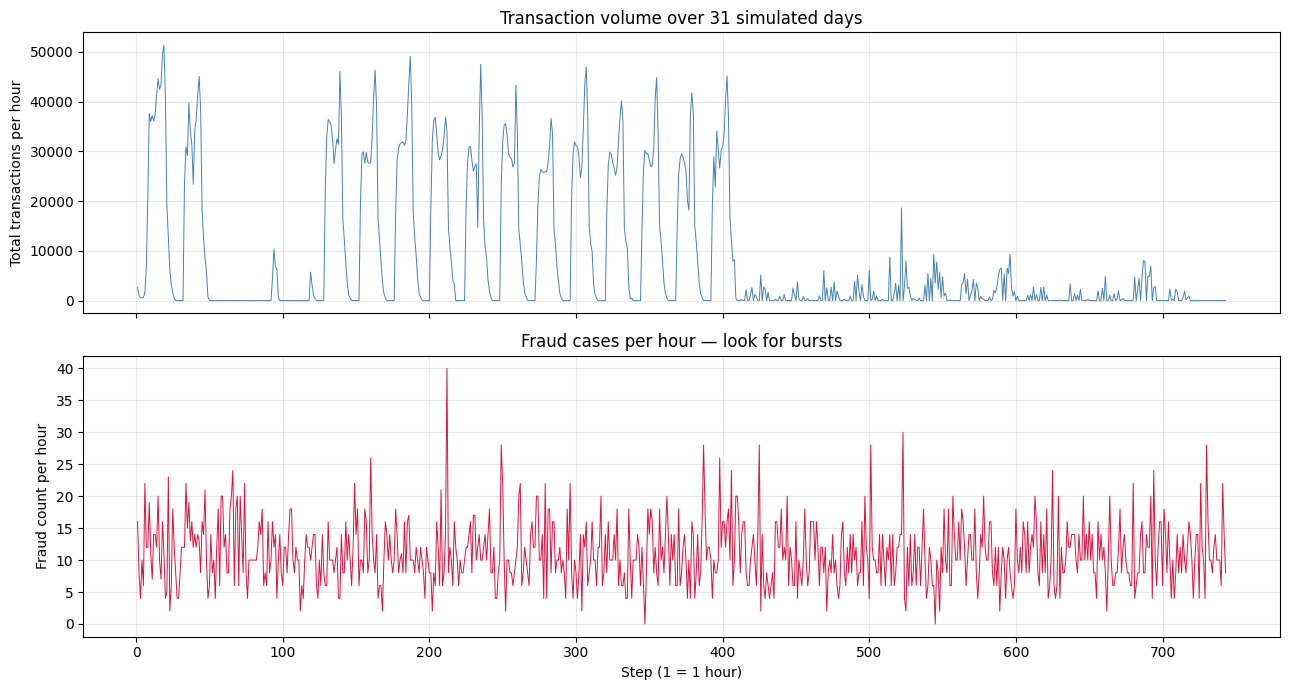

Saved figure to data/processed/fig_fraud_temporal.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: total transaction volume per hour
axes[0].plot(fraud_per_step.index, fraud_per_step['total_count'], color='steelblue', linewidth=0.7)
axes[0].set_ylabel('Total transactions per hour')
axes[0].set_title('Transaction volume over 31 simulated days')
axes[0].grid(alpha=0.3)

# Bottom: fraud per hour
axes[1].plot(fraud_per_step.index, fraud_per_step['fraud_count'], color='crimson', linewidth=0.7)
axes[1].set_ylabel('Fraud count per hour')
axes[1].set_xlabel('Step (1 = 1 hour)')
axes[1].set_title('Fraud cases per hour — look for bursts')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/fig_fraud_temporal.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure to data/processed/fig_fraud_temporal.png")


In [14]:
# Q6b — Time gap between consecutive transactions from the same sender account
df_sorted = df.sort_values(['nameOrig', 'step']).copy()
df_sorted['time_gap'] = df_sorted.groupby('nameOrig', observed=True)['step'].diff()

# Compare time-gaps for fraud vs legitimate
gap_stats = df_sorted.dropna(subset=['time_gap']).groupby('isFraud', observed=True)['time_gap'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
)
print("Time-gap (in hours) between consecutive transactions from the same sender:\n")
print(gap_stats.round(2))

print(f"\nFraction of fraud with time_gap == 0 (same hour as previous):  "
      f"{((df_sorted['isFraud']==1) & (df_sorted['time_gap']==0)).sum() / df_sorted['isFraud'].sum() * 100:.2f}%")
print(f"Fraction of legit with time_gap == 0:                           "
      f"{((df_sorted['isFraud']==0) & (df_sorted['time_gap']==0)).sum() / (df_sorted['isFraud']==0).sum() * 100:.2f}%")


Time-gap (in hours) between consecutive transactions from the same sender:

          count    mean     std   min    25%    50%    75%    95%    max
isFraud                                                                 
0        9295.0  158.15  123.54   0.0   56.0  139.0  225.0  383.0  704.0
1          18.0  242.56  157.48  11.0  111.5  241.5  336.5  471.1  500.0

Fraction of fraud with time_gap == 0 (same hour as previous):  0.00%
Fraction of legit with time_gap == 0:                           0.00%


In [15]:
# Q7 — Does fraud drain the sender's balance?
df_relevant = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Drain ratio: how much of the sender's pre-transaction balance was sent?
# Safe division — avoid divide-by-zero
df_relevant['drain_ratio'] = np.where(
    df_relevant['oldbalanceOrg'] > 0,
    df_relevant['amount'] / df_relevant['oldbalanceOrg'],
    0,  # if pre-balance was 0, drain ratio is undefined → 0
)

# Three forensic flags
df_relevant['src_drained'] = (df_relevant['newbalanceOrig'] == 0).astype(int)
df_relevant['dst_was_empty'] = (df_relevant['oldbalanceDest'] == 0).astype(int)

# Compare these signals between fraud and legitimate
print("Drain & balance flags — fraud vs legitimate:\n")
summary = df_relevant.groupby('isFraud', observed=True).agg(
    mean_drain_ratio=('drain_ratio', 'mean'),
    pct_src_drained=('src_drained', 'mean'),
    pct_dst_was_empty=('dst_was_empty', 'mean'),
)
summary[['pct_src_drained', 'pct_dst_was_empty']] *= 100
print(summary.round(4))


Drain & balance flags — fraud vs legitimate:

         mean_drain_ratio  pct_src_drained  pct_dst_was_empty
isFraud                                                      
0              145.972794          90.0951            13.9009
1                0.993800          98.0519            65.1528


In [16]:
# Q7b — How often does fraud have BOTH src_drained AND dst_was_empty?
both_flags = (df_relevant['src_drained'] == 1) & (df_relevant['dst_was_empty'] == 1)

print("Combined signature: src_drained AND dst_was_empty\n")
print(f"Fraud cases with BOTH flags:          {((df_relevant['isFraud']==1) & both_flags).sum():>6,}  ({((df_relevant['isFraud']==1) & both_flags).sum() / (df_relevant['isFraud']==1).sum() * 100:.2f}% of all fraud)")
print(f"Legit cases with BOTH flags:          {((df_relevant['isFraud']==0) & both_flags).sum():>6,}  ({((df_relevant['isFraud']==0) & both_flags).sum() / (df_relevant['isFraud']==0).sum() * 100:.2f}% of legit)")

# Lift: how much more likely is fraud given both flags?
p_fraud_given_both = ((df_relevant['isFraud']==1) & both_flags).sum() / both_flags.sum()
p_fraud_baseline = (df_relevant['isFraud']==1).mean()
print(f"\nBaseline fraud rate (TRANSFER+CASH_OUT): {p_fraud_baseline*100:.4f}%")
print(f"Fraud rate when BOTH flags fire:        {p_fraud_given_both*100:.4f}%")
print(f"Lift:                                   {p_fraud_given_both / p_fraud_baseline:.1f}×")


Combined signature: src_drained AND dst_was_empty

Fraud cases with BOTH flags:           5,193  (63.23% of all fraud)
Legit cases with BOTH flags:          321,377  (11.63% of legit)

Baseline fraud rate (TRANSFER+CASH_OUT): 0.2965%
Fraud rate when BOTH flags fire:        1.5902%
Lift:                                   5.4×


In [17]:
# Q7c — How many times is the same destination account hit?
# Senders are one-shot (Finding 1), so the receiver side is where the structure lives.

dest_activity = df_relevant.groupby('nameDest', observed=True).agg(
    times_received=('isFraud', 'size'),
    fraud_received=('isFraud', 'sum'),
)
dest_activity['fraud_rate'] = dest_activity['fraud_received'] / dest_activity['times_received']

print("How many transactions does each destination account receive? (TRANSFER + CASH_OUT)\n")
print(dest_activity['times_received'].describe(percentiles=[0.5, 0.9, 0.99, 0.999]).round(2))

# Top 15 hottest mule candidates
print("\nTop 15 destinations by fraud count received:")
hot_mules = dest_activity[dest_activity['fraud_received'] > 0].sort_values('fraud_received', ascending=False).head(15)
print(hot_mules)

# Median of drain_ratio (correcting Finding 4)
print("\n--- Drain ratio MEDIAN (correcting outlier-skewed mean) ---")
print(df_relevant.groupby('isFraud', observed=True)['drain_ratio'].median().round(4))


How many transactions does each destination account receive? (TRANSFER + CASH_OUT)

count    509565.00
mean          5.44
std           5.78
min           1.00
50%           3.00
90%          13.00
99%          28.00
99.9%        39.00
max          75.00
Name: times_received, dtype: float64

Top 15 destinations by fraud count received:
             times_received  fraud_received  fraud_rate
nameDest                                               
C964377943                4               2    0.500000
C1325541393              19               2    0.105263
C1366192319               9               2    0.222222
C644163395               16               2    0.125000
C1980653895              24               2    0.083333
C1656842502               8               2    0.250000
C1601170327              14               2    0.142857
C650699445                8               2    0.250000
C475338087               13               2    0.153846
C1653587362               7               2   

In [18]:
# Q8 — Pick the hottest mule and trace the network around it
top_mule = hot_mules.index[0]   # the destination that received the most fraud
print(f"Investigating mule destination: {top_mule}")
print(f"  Fraud transactions received: {hot_mules.loc[top_mule, 'fraud_received']}")
print(f"  Total transactions received: {hot_mules.loc[top_mule, 'times_received']}\n")

# All transactions involving this account (as sender OR receiver)
ring = df[(df['nameOrig'] == top_mule) | (df['nameDest'] == top_mule)].copy()
print(f"Transactions touching {top_mule}: {len(ring)}\n")

# Show the receivers of those who SEND TO this mule
# (i.e., what does the fraud network around this mule look like?)
senders_to_mule = df[df['nameDest'] == top_mule].copy()
print(f"Direct senders to {top_mule} (1-hop):")
print(senders_to_mule[['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud']].head(20))

# Now look at what those senders did BEFORE they sent to the mule
# (i.e., 2-hop neighborhood — who fed money into the senders?)
sender_ids = senders_to_mule['nameOrig'].unique()
print(f"\nUnique senders to mule: {len(sender_ids)}")
print(f"\nExample 2-hop trace — pick the first sender and see who funded them:")
first_sender = sender_ids[0]
funders = df[df['nameDest'] == first_sender]
print(f"\nWho funded {first_sender}?")
print(funders[['step', 'type', 'amount', 'nameOrig', 'isFraud']].head(10))


Investigating mule destination: C964377943
  Fraud transactions received: 2
  Total transactions received: 4

Transactions touching C964377943: 4

Direct senders to C964377943 (1-hop):
         step      type        amount     nameOrig  oldbalanceOrg  \
4058811   300  CASH_OUT  1.760592e+05  C1203474575   1.760592e+05   
4656648   330  CASH_OUT  4.643095e+04   C280723002   2.070600e+04   
5673348   397  CASH_OUT  1.434849e+05  C2084687045   0.000000e+00   
5801852   401  CASH_OUT  5.838803e+06   C388640141   5.838803e+06   

         newbalanceOrig  isFraud  
4058811             0.0        1  
4656648             0.0        0  
5673348             0.0        0  
5801852             0.0        1  

Unique senders to mule: 4

Example 2-hop trace — pick the first sender and see who funded them:

Who funded C1203474575?
Empty DataFrame
Columns: [step, type, amount, nameOrig, isFraud]
Index: []


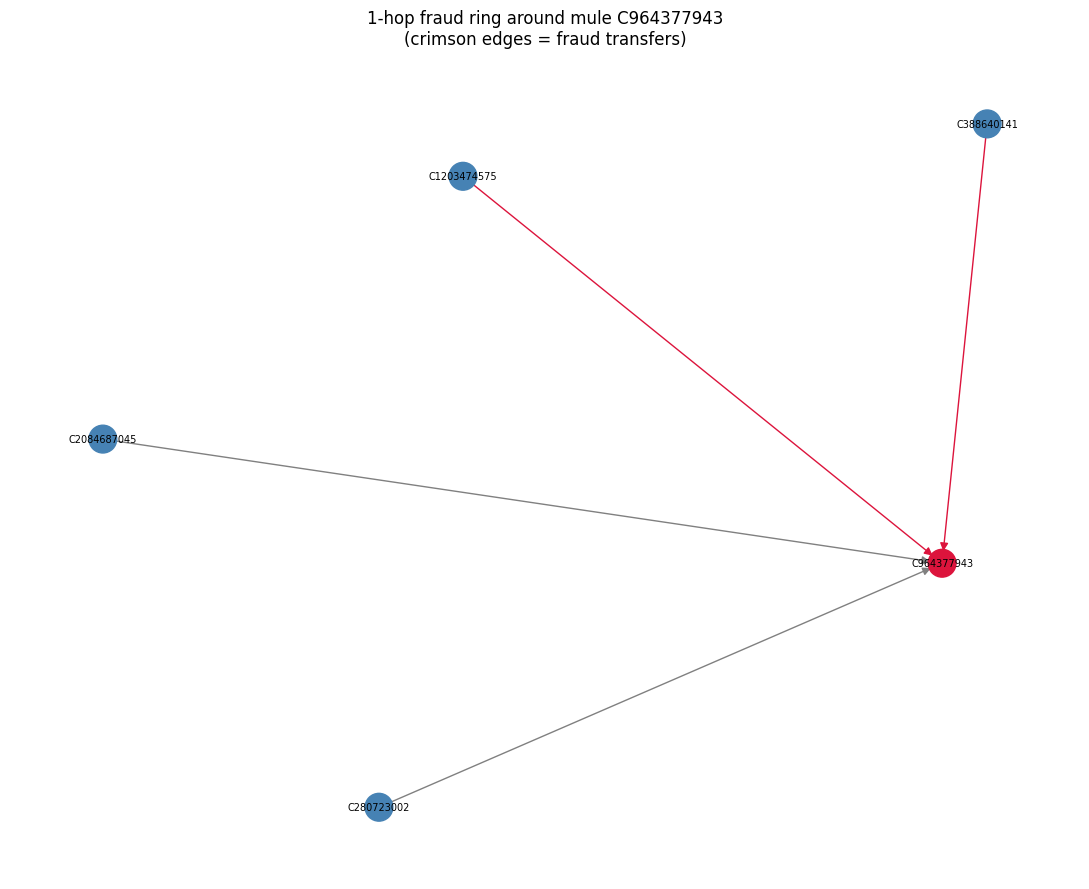

Saved figure to data/processed/fig_fraud_ring.png


In [19]:
import networkx as nx

# Build a small NetworkX graph of the fraud ring
G = nx.DiGraph()

# Add all senders → mule
for _, row in senders_to_mule.head(20).iterrows():  # cap to 20 for readability
    G.add_edge(
        row['nameOrig'], row['nameDest'],
        amount=row['amount'], fraud=int(row['isFraud'])
    )

# Color nodes — mule is red, senders blue
node_colors = ['crimson' if n == top_mule else 'steelblue' for n in G.nodes()]
edge_colors = ['crimson' if G.edges[e]['fraud'] == 1 else 'gray' for e in G.edges()]

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(G, seed=42, k=0.7)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, arrows=True, arrowsize=12, ax=ax)
ax.set_title(f"1-hop fraud ring around mule {top_mule}\n(crimson edges = fraud transfers)")
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/fig_fraud_ring.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved figure to data/processed/fig_fraud_ring.png")


In [20]:
# Q8b — Does the mule send money to anyone after receiving fraud?
print(f"Looking for outgoing transactions from mule {top_mule}...\n")
mule_outgoing = df[df['nameOrig'] == top_mule]
print(f"Outgoing transactions: {len(mule_outgoing)}")
if len(mule_outgoing) > 0:
    print(mule_outgoing[['step', 'type', 'amount', 'nameDest', 'isFraud']])
else:
    print("→ This mule never sent. Money stops here (CASH_OUT pattern — withdrawal).")

# Try a different mule — find one that BOTH received fraud AND sent transactions
print("\n\n--- Looking for mules that BOTH received fraud AND sent money on ---\n")

# Get all destinations that received fraud
fraud_destinations = set(df[df['isFraud'] == 1]['nameDest'].unique())
# Get all senders that also appear as fraud-destinations (i.e., possible relay mules)
relay_mules = fraud_destinations.intersection(set(df['nameOrig'].unique()))
print(f"Accounts that received fraud AND later sent money: {len(relay_mules):,}")

if len(relay_mules) > 0:
    # Pick one and trace the chain
    relay = list(relay_mules)[0]
    inbound = df[df['nameDest'] == relay]
    outbound = df[df['nameOrig'] == relay]
    print(f"\nExample relay mule: {relay}")
    print(f"  Inbound transactions ({len(inbound)}):")
    print(inbound[['step', 'type', 'amount', 'nameOrig', 'isFraud']])
    print(f"\n  Outbound transactions ({len(outbound)}):")
    print(outbound[['step', 'type', 'amount', 'nameDest', 'isFraud']])


Looking for outgoing transactions from mule C964377943...

Outgoing transactions: 0
→ This mule never sent. Money stops here (CASH_OUT pattern — withdrawal).


--- Looking for mules that BOTH received fraud AND sent money on ---

Accounts that received fraud AND later sent money: 18

Example relay mule: C1023330867
  Inbound transactions (1):
         step      type      amount     nameOrig  isFraud
6362556   738  TRANSFER  814689.875  C2029041842        1

  Outbound transactions (1):
         step      type        amount     nameDest  isFraud
1168398   132  CASH_OUT  29084.279297  C1422447255        0
